In [ ]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import h5py
import hdf5plugin
import matplotlib
import numpy as np
from utils import job


%matplotlib inline
import os
plt.style.use('dark_background')

job.info()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
hostname: offline-cn8
SLURM_JOB_ID: 464351
SLURM_JOB_NODELIST: offline-cn8
NPROCS: 8


In [4]:
root = '/data/visitors/danmax/20251117/2025110808/'
raw = os.path.join(root , 'raw')
sample = os.path.join(raw , 'al1050_15pct_center_slice')

In [5]:
omega = np.load('omega_al.npy')
dty = np.load('dty_al.npy')
I = np.load('sum_ints_al.npy')

In [6]:
uni_omega = np.unique(np.round(omega, 3))
uni_dty = np.unique(np.round(dty, 3))
number_of_omega_steps = uni_omega.size
number_of_dty_steps = uni_dty.size
omega_step = np.mean(np.diff(uni_omega))
dty_step = np.mean(np.diff(uni_dty))

In [7]:
np.diff(np.unique(np.round(dty, 4))).shape

(150,)

In [8]:
np.diff(np.unique(np.round(dty, 10))).shape

(150,)

In [9]:
np.diff(np.unique(dty))

array([1.00000000e-02, 1.00000000e-02, 1.00000000e-02, 1.00000000e-02,
       1.00000000e-02, 1.00000000e-02, 1.00000000e-02, 1.00000000e-02,
       1.00000000e-02, 1.00000000e-02, 1.00000000e-02, 1.00000000e-02,
       1.00000000e-02, 1.00000000e-02, 1.00000000e-02, 1.00000000e-02,
       1.00000000e-02, 1.00000000e-02, 1.00000000e-02, 1.00000000e-02,
       1.00000000e-02, 1.00000000e-02, 1.00000000e-02, 1.00000000e-02,
       1.00000000e-02, 1.00000000e-02, 1.00000000e-02, 1.00000000e-02,
       1.00000000e-02, 5.55111512e-17, 1.00000000e-02, 5.55111512e-17,
       1.00000000e-02, 1.00000000e-02, 1.00000000e-02, 1.00000000e-02,
       1.00000000e-02, 1.00000000e-02, 1.00000000e-02, 1.00000000e-02,
       1.00000000e-02, 1.00000000e-02, 1.00000000e-02, 1.00000000e-02,
       5.55111512e-17, 1.00000000e-02, 1.00000000e-02, 1.00000000e-02,
       1.00000000e-02, 1.00000000e-02, 1.00000000e-02, 1.00000000e-02,
       1.00000000e-02, 1.00000000e-02, 1.00000000e-02, 1.00000000e-02,
      

In [10]:
sino, xedges, yedges = np.histogram2d(dty, omega, bins=(number_of_dty_steps, number_of_omega_steps), weights=I)
counts, xedges, yedges = np.histogram2d(dty, omega, bins=(number_of_dty_steps, number_of_omega_steps), weights=np.ones_like(I))
sino /= counts

In [11]:
sino /= np.max(sino, axis=0)

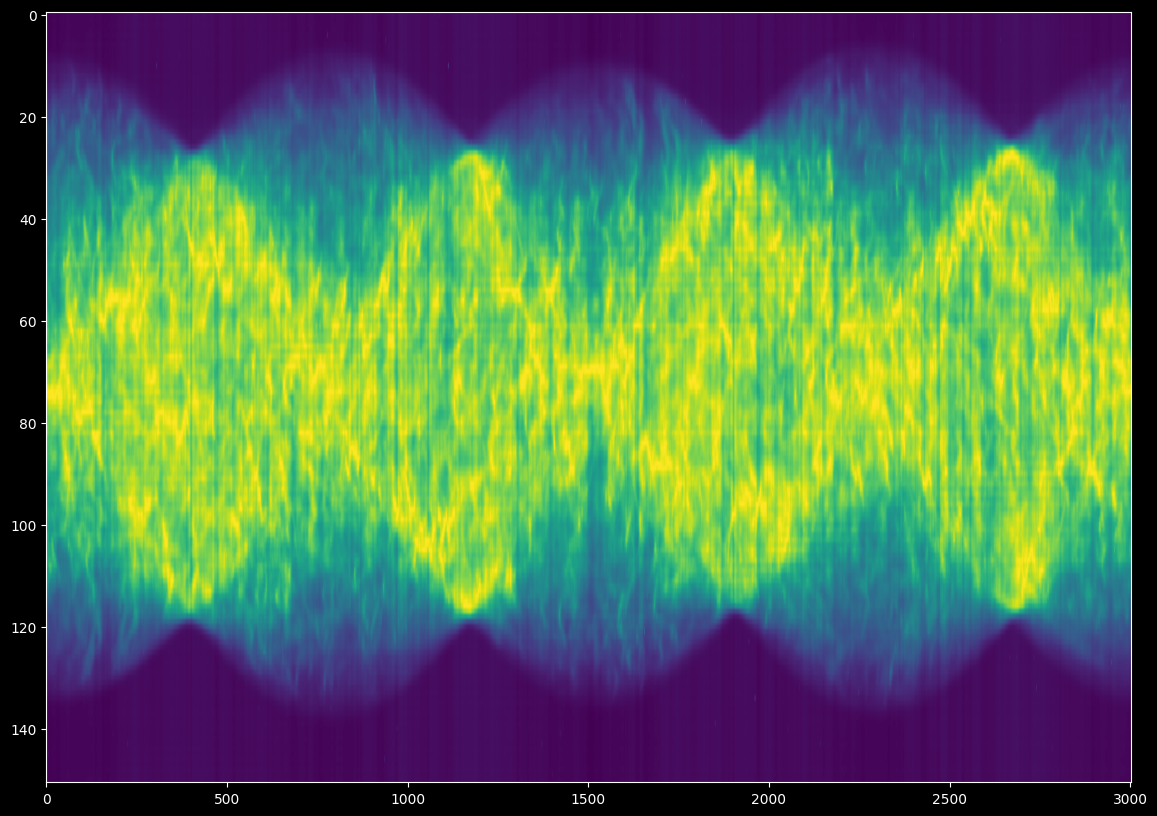

In [12]:
plt.figure(figsize=(14, 10))
plt.imshow(sino, aspect='auto')
plt.show()

In [13]:
xedges[len(xedges) // 2 - 2: len(xedges) // 2 + 2]

array([-0.01490066, -0.00496689,  0.00496689,  0.01490066])

In [14]:
xedges.shape

(152,)

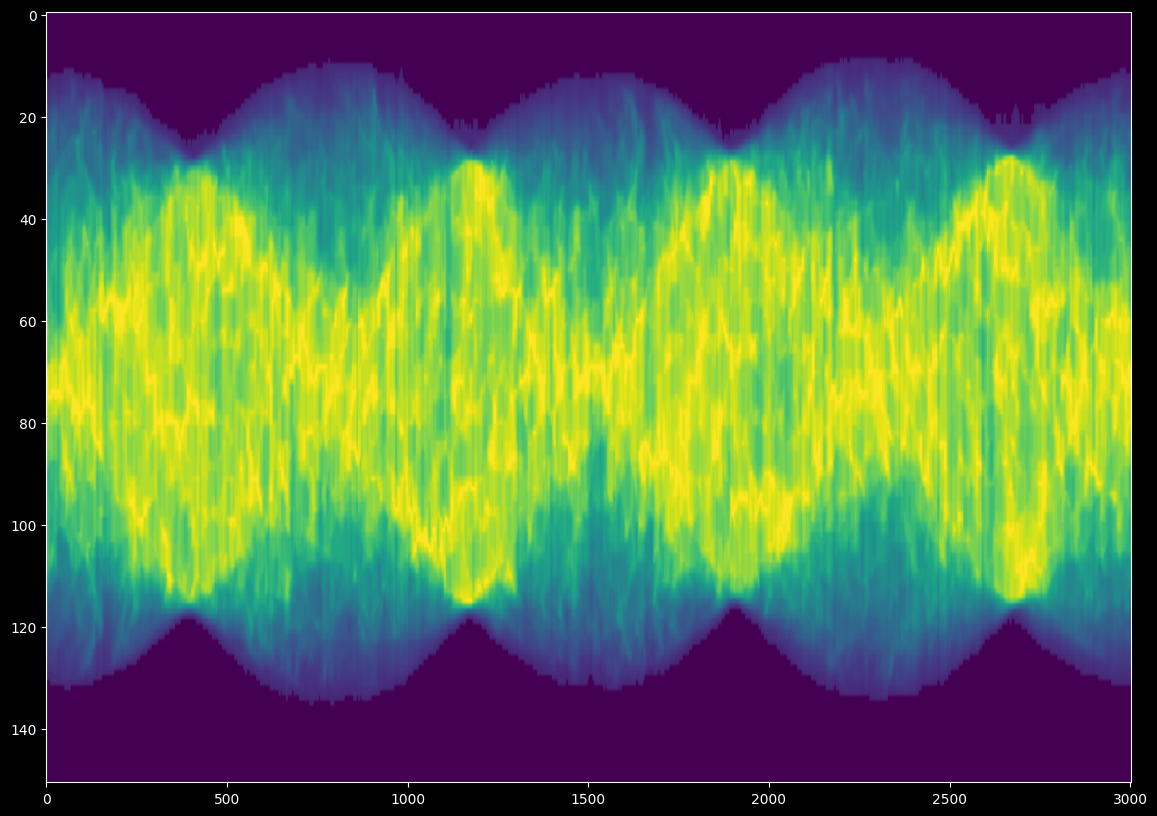

In [15]:
from scipy.ndimage import median_filter, minimum_filter, maximum_filter, gaussian_filter
from skimage.transform import iradon

msino = minimum_filter(sino, (5, 1)) # kill hot pixels
msino = maximum_filter(msino, (1, 5)) # fill low intensity peak gaps
msino[msino < np.max(msino) * 0.1] = 0
#msino = gaussian_filter(msino, (1, 2)) # denoise
msino = msino / np.max(msino, axis=0) # renormalize

plt.figure(figsize=(14, 10))
plt.imshow(msino, aspect='auto')
plt.show()

In [241]:
recs = [ (iradon(np.roll(msino, i, axis=0), theta=uni_omega), i) for i in range(-1, 7, 1) ]

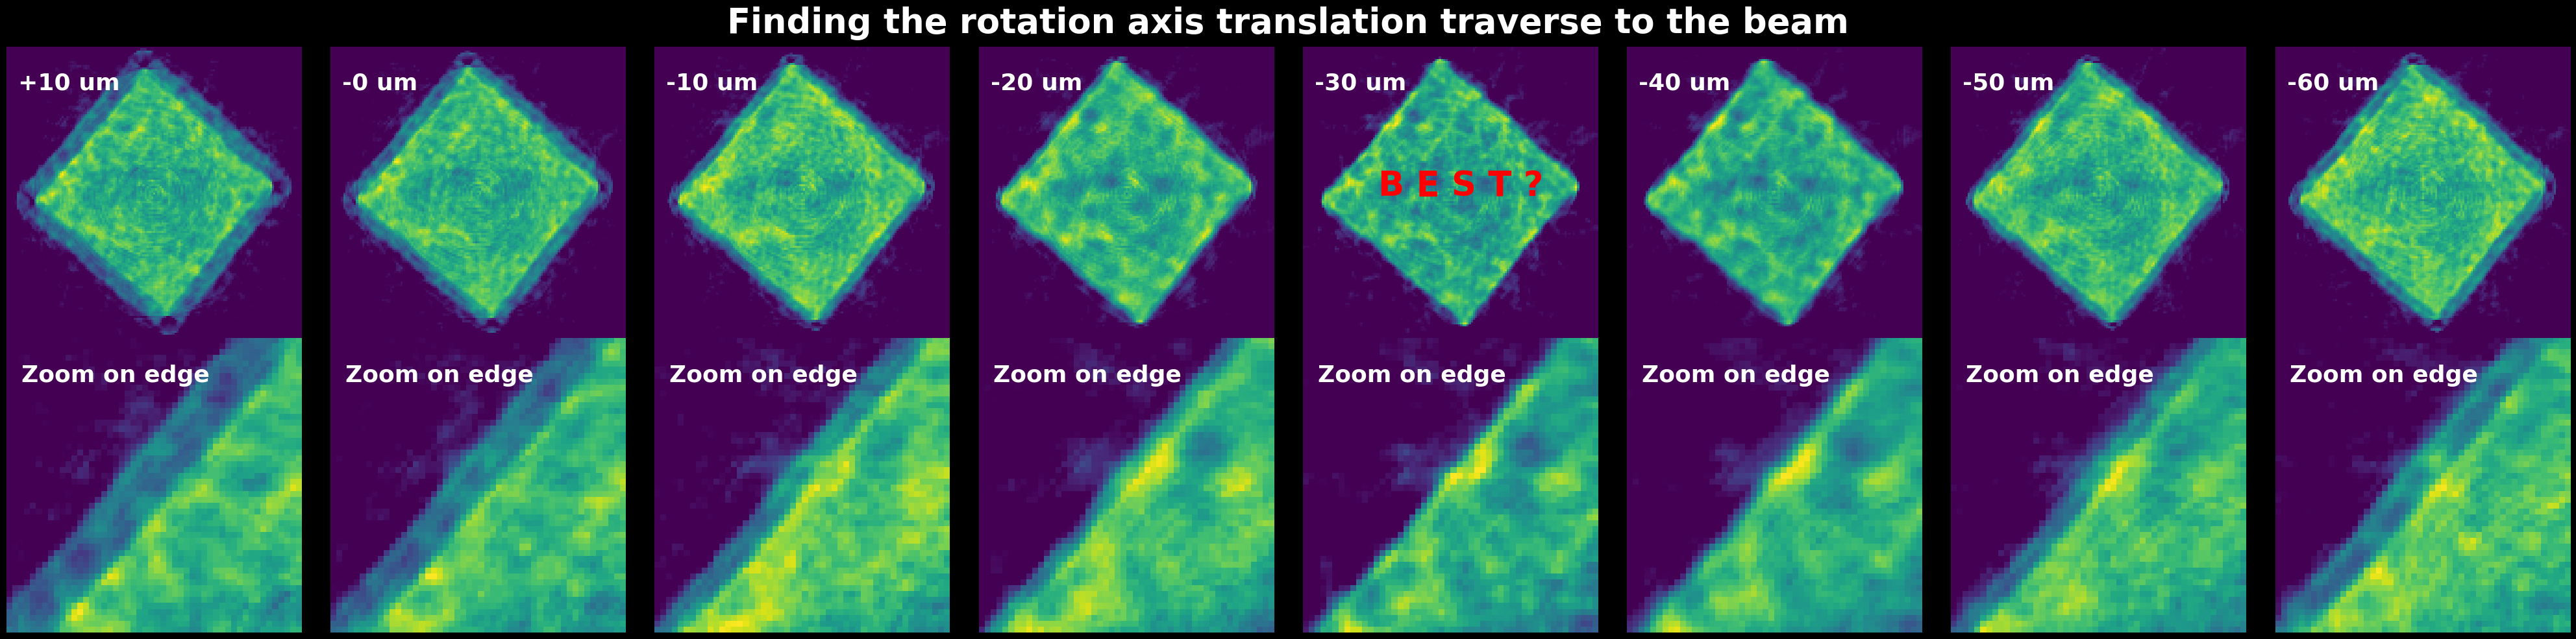

In [247]:
fig, ax = plt.subplots(2, len(recs), figsize=(40, 10))
for i in range(len(recs)):
    rr, ii = recs[i]
    ax[0,i].imshow(rr.clip(np.max(rr)*0.1)[6:-6, 6:-6], interpolation='nearest')
    s = '+' if ii<0 else '-'
    ax[0,i].text(5, 20, s + str(abs(np.round(ii*dty_step*1000,0).astype(int)))+' um', fontsize=26, fontweight='bold')
    ax[1,i].text(2, 7, 'Zoom on edge', fontsize=26, fontweight='bold')
    if ii==3:
        ax[0,i].text(35, 70, 'B E S T ?', fontsize=38, color='r', fontweight='bold')
    ax[1,i].imshow(rr.clip(np.max(rr)*0.1)[20:70, 20:70], interpolation='nearest')
for a in ax.flatten():
    a.axis('off')
    for spine in a.spines.values():
        spine.set_visible(False)
fig.suptitle('Finding the rotation axis translation traverse to the beam', fontsize=38, fontweight='bold')
plt.tight_layout()
fig.savefig('finding_rotation_axis.png', dpi=400)
plt.show()

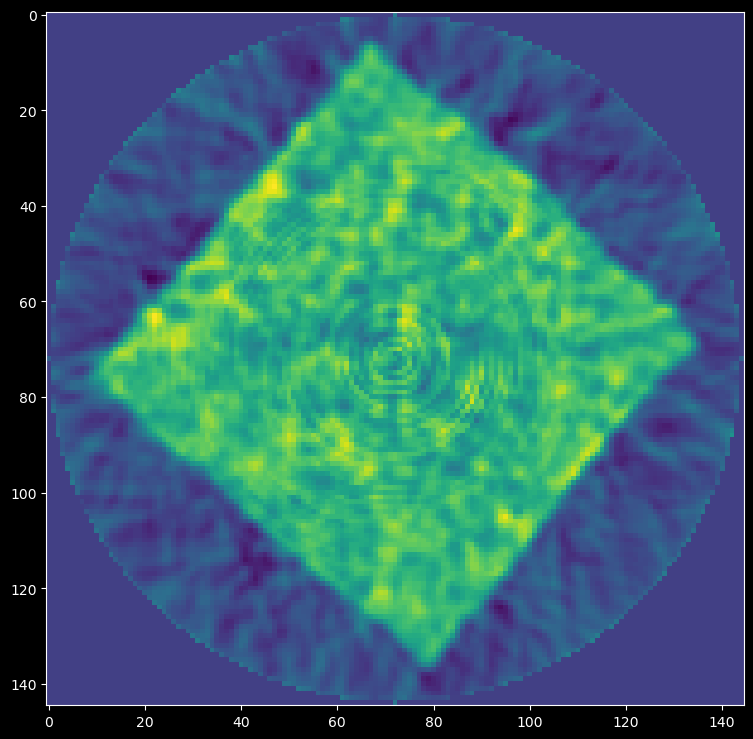

In [53]:
from skimage.transform import iradon
reconstruction_fbp = iradon(sino[:-6], theta=uni_omega, filter_name='ramp') #ramp, shepp-logan, cosine, hamming, hann
plt.figure(figsize=(9, 9))
plt.imshow(reconstruction_fbp, aspect='auto')
plt.show()

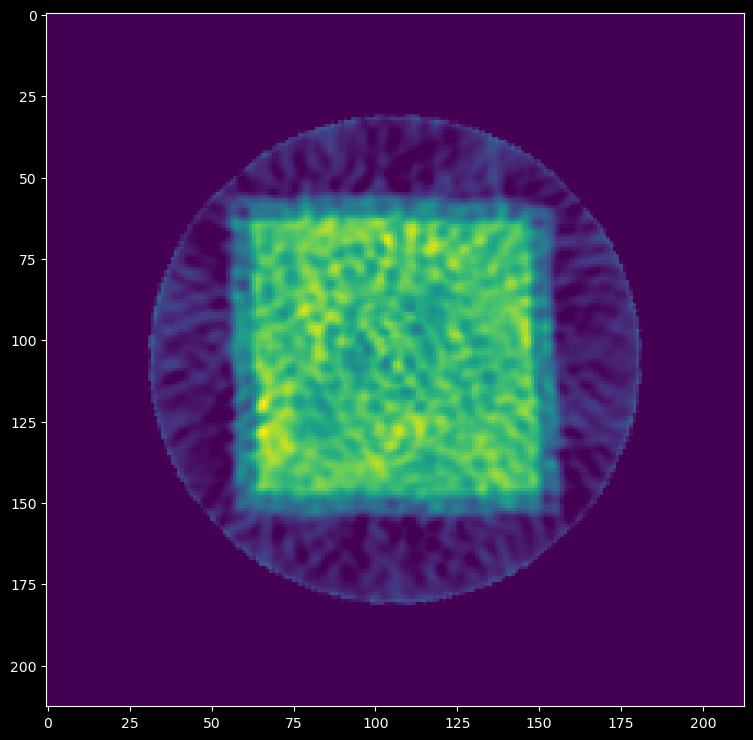

In [19]:
from scipy.ndimage import rotate
reconstruction_fbp_rot = rotate(reconstruction_fbp, angle=41, axes=(1, 0))
plt.figure(figsize=(9, 9))
plt.imshow(reconstruction_fbp_rot.clip(0), aspect='auto', interpolation='nearest')
plt.show()

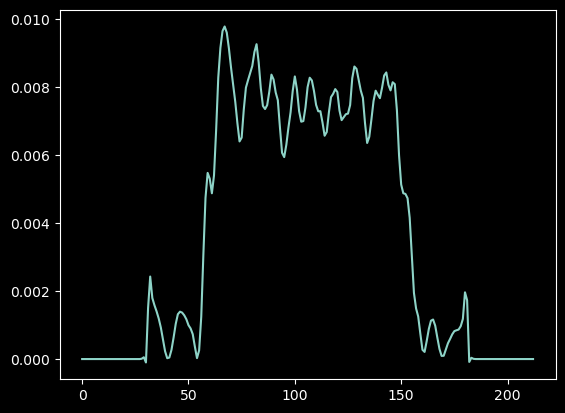

In [25]:
plt.figure()
plt.plot(reconstruction_fbp_rot[110])
plt.show()